In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
pip install pandas scikit-learn pytz matplotlib seaborn numpy

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/11.5 MB 16.8 MB/s eta 0:00:01
   ------------------------- -------------- 7.3/11.5 MB 17.4 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.5 MB 18.0 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 14.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ------------- -------------------------- 3.7/11.1 MB 16.8 MB/s eta 0:00:01
   -----

In [1]:
import pandas as pd
import sklearn
import pytz # dealing with time zone
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# if running on local
model_set = pd.read_csv('taxi-train.csv')
predict_set = pd.read_csv('taxi-test.csv')

# # if running on google colab
# model_set = pd.read_csv('/content/drive/MyDrive/06 PG/01 SMU/01 Course/02 Track Core/03 CS610 Applied Machine Learning/11 Assignments/02 Assignment 2/taxi-train.csv')
# predict_set = pd.read_csv('/content/drive/MyDrive/06 PG/01 SMU/01 Course/02 Track Core/03 CS610 Applied Machine Learning/11 Assignments/02 Assignment 2/taxi-test.csv')

### Data Set Checking

#### Model Set

In [3]:
print("---------------------------------------------------------------------")
print(model_set.head(10))
print("---------------------------------------------------------------------")
print(model_set.info())
print("---------------------------------------------------------------------")
print(model_set.describe())
print("---------------------------------------------------------------------")
print(model_set['vendor_id'].unique())
print("---------------------------------------------------------------------")
print(model_set['rate_code'].unique())
print("---------------------------------------------------------------------")
print(model_set['payment_type'].unique())

---------------------------------------------------------------------
  vendor_id            pickup_datetime           dropoff_datetime  \
0       CMT  2013-11-03 18:11:18+00:00  2013-11-03 18:18:43+00:00   
1       CMT  2010-06-30 17:30:34+00:00  2010-06-30 17:40:44+00:00   
2       CMT  2010-03-03 10:10:25+00:00  2010-03-03 10:19:38+00:00   
3       VTS  2012-04-17 11:51:00+00:00  2012-04-17 12:07:00+00:00   
4       VTS  2012-03-30 14:26:00+00:00  2012-03-30 14:36:00+00:00   
5       CMT  2012-09-04 15:56:18+00:00  2012-09-04 16:15:40+00:00   
6       VTS  2013-05-27 19:43:00+00:00  2013-05-27 19:53:00+00:00   
7       CMT  2014-07-12 16:17:19+00:00  2014-07-12 16:25:01+00:00   
8       VTS  2011-11-04 11:35:00+00:00  2011-11-04 11:56:00+00:00   
9       CMT  2011-09-03 08:08:17+00:00  2011-09-03 08:19:28+00:00   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.971879        40.756228         -73.971428         40.764175   
1        -73.977

#### Prediction Set

In [4]:
print("---------------------------------------------------------------------")
print(predict_set.head(10))
print("---------------------------------------------------------------------")
print(predict_set.info())
print("---------------------------------------------------------------------")
print(predict_set.describe())
print("---------------------------------------------------------------------")
print(predict_set['vendor_id'].unique())
print("---------------------------------------------------------------------")
print(predict_set['rate_code'].unique())
print("---------------------------------------------------------------------")
print(predict_set['payment_type'].unique())

---------------------------------------------------------------------
  vendor_id            pickup_datetime           dropoff_datetime  \
0       VTS  2009-03-19 15:13:00+00:00  2009-03-19 15:23:00+00:00   
1       CMT  2009-10-26 08:38:03+00:00  2009-10-26 08:45:14+00:00   
2       CMT  2015-06-12 07:15:51+00:00  2015-06-12 07:25:29+00:00   
3       CMT  2012-06-08 22:01:46+00:00  2012-06-08 22:08:41+00:00   
4       CMT  2009-08-10 20:10:37+00:00  2009-08-10 20:13:50+00:00   
5       VTS  2009-09-14 21:34:00+00:00  2009-09-14 21:44:00+00:00   
6       VTS  2015-01-19 15:20:33+00:00  2015-01-19 15:29:40+00:00   
7       VTS  2013-03-23 12:34:00+00:00  2013-03-23 12:46:00+00:00   
8       VTS  2013-05-14 08:03:00+00:00  2013-05-14 08:10:00+00:00   
9       VTS  2015-04-17 21:19:14+00:00  2015-04-17 21:39:06+00:00   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.988103        40.759927         -73.974167         40.753982   
1        -73.975

### Data Splitting

In [5]:
model_features = model_set.drop(["tip_amount", "fare_amount"], axis=1)
model_labels = model_set[["tip_amount", "fare_amount"]]

print(model_features.head())
print(model_labels.head())

  vendor_id            pickup_datetime           dropoff_datetime  \
0       CMT  2013-11-03 18:11:18+00:00  2013-11-03 18:18:43+00:00   
1       CMT  2010-06-30 17:30:34+00:00  2010-06-30 17:40:44+00:00   
2       CMT  2010-03-03 10:10:25+00:00  2010-03-03 10:19:38+00:00   
3       VTS  2012-04-17 11:51:00+00:00  2012-04-17 12:07:00+00:00   
4       VTS  2012-03-30 14:26:00+00:00  2012-03-30 14:36:00+00:00   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.971879        40.756228         -73.971428         40.764175   
1        -73.977850        40.738361         -73.977073         40.754229   
2        -73.974089        40.762479         -73.990669         40.745668   
3        -73.979920        40.781045         -73.970415         40.765608   
4        -73.972975        40.761610         -73.955615         40.764290   

   rate_code  passenger_count  trip_distance payment_type  tip_paid  
0        1.0                1           0.80        

In [6]:
from sklearn.model_selection import train_test_split # <--- Make sure this import is present

In [7]:
# data spliiting
# 80% training, 10% validation and 10% testing
x_train, x_temp, y_train, y_temp = train_test_split(model_features, model_labels, test_size=0.2, random_state = 2025, shuffle=True)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state = 2025, shuffle=True)

### Initial EDA

#### Basic Information

In [8]:
## check missing values
print("-------------Training data set---------------")
print(x_train.isnull().sum())
print("-------------Validation data set---------------")
print(x_val.isnull().sum())
print("-------------Test data set---------------")
print(x_test.isnull().sum())

-------------Training data set---------------
vendor_id                 0
pickup_datetime           0
dropoff_datetime          0
pickup_longitude          0
pickup_latitude           0
dropoff_longitude         0
dropoff_latitude          0
rate_code            138571
passenger_count           0
trip_distance             0
payment_type              0
tip_paid                  0
dtype: int64
-------------Validation data set---------------
vendor_id                0
pickup_datetime          0
dropoff_datetime         0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude         0
rate_code            17395
passenger_count          0
trip_distance            0
payment_type             0
tip_paid                 0
dtype: int64
-------------Test data set---------------
vendor_id                0
pickup_datetime          0
dropoff_datetime         0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude

In [9]:
# check information and type
print("-------------Training data set---------------")
print(x_train.info())
print("-------------Validation data set---------------")
print(x_val.info())
print("-------------Test data set---------------")
print(x_test.info())

-------------Training data set---------------
<class 'pandas.core.frame.DataFrame'>
Index: 857528 entries, 234510 to 1006142
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   vendor_id          857528 non-null  object 
 1   pickup_datetime    857528 non-null  object 
 2   dropoff_datetime   857528 non-null  object 
 3   pickup_longitude   857528 non-null  float64
 4   pickup_latitude    857528 non-null  float64
 5   dropoff_longitude  857528 non-null  float64
 6   dropoff_latitude   857528 non-null  float64
 7   rate_code          718957 non-null  float64
 8   passenger_count    857528 non-null  int64  
 9   trip_distance      857528 non-null  float64
 10  payment_type       857528 non-null  object 
 11  tip_paid           857528 non-null  int64  
dtypes: float64(6), int64(2), object(4)
memory usage: 85.1+ MB
None
-------------Validation data set---------------
<class 'pandas.core.frame.DataFrame'>
In

In [10]:
# rate code should be categorical feature rather than numeric feature
x_train['rate_code'] = x_train['rate_code'].astype('category')
x_val['rate_code'] = x_val['rate_code'].astype('category')
x_test['rate_code'] = x_test['rate_code'].astype('category')

#### Descriptive Analytics

In [11]:
print("-------------Training data set---------------")
print(x_train.describe())
print("-------------Validation data set---------------")
print(x_val.describe())
print("-------------Test data set---------------")
print(x_test.describe())

## no outliers detected in the pickup area, passenger_count, trip distance and tip_paid

-------------Training data set---------------
       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
count     857528.000000    857528.000000      857528.000000     857528.000000   
mean         -73.977064        40.756846         -73.975550         40.757264   
std            0.014379         0.018198           0.015731          0.018854   
min          -73.999999        40.700005         -73.999999         40.700005   
25%          -73.988155        40.744772         -73.987297         40.745297   
50%          -73.979816        40.757832         -73.978580         40.758247   
75%          -73.968127        40.769453         -73.966512         40.770450   
max          -73.900009        40.799997         -73.900008         40.799999   

       passenger_count  trip_distance       tip_paid  
count    857528.000000  857528.000000  857528.000000  
mean          1.692474       1.812576       0.422902  
std           1.313169       1.221050       0.494020  
min 

#### Categorical Features

#### Date and Time

Summary Operations:
1. cast into datetime type and convert from UTC to EST
2. identify the day of the pickup time
3. identify the hour of pickup time and dropoff time
4. visualise the volume of orders by pickup and dropoff per hour

In [12]:
# Date and Time
us_east = pytz.timezone('US/Eastern')
# cast into datetime type and convert utc to est
x_train['pickup_datetime_est'] = pd.to_datetime(x_train['pickup_datetime']).dt.tz_convert(us_east)
x_val['pickup_datetime_est'] = pd.to_datetime(x_val['pickup_datetime']).dt.tz_convert(us_east)
x_test['pickup_datetime_est'] = pd.to_datetime(x_test['pickup_datetime']).dt.tz_convert(us_east)

x_train['dropoff_datetime_est'] = pd.to_datetime(x_train['dropoff_datetime']).dt.tz_convert(us_east)
x_val['dropoff_datetime_est'] = pd.to_datetime(x_val['dropoff_datetime']).dt.tz_convert(us_east)
x_test['dropoff_datetime_est'] = pd.to_datetime(x_test['dropoff_datetime']).dt.tz_convert(us_east)

In [13]:
x_train['pickup_day'] = x_train['pickup_datetime_est'].dt.day_name()
x_val['pickup_day'] = x_val['pickup_datetime_est'].dt.day_name()
x_test['pickup_day'] = x_test['pickup_datetime_est'].dt.day_name()

x_train['dropoff_day'] = x_train['dropoff_datetime_est'].dt.day_name()
x_val['dropoff_day'] = x_val['dropoff_datetime_est'].dt.day_name()
x_test['dropoff_day'] = x_test['dropoff_datetime_est'].dt.day_name()

x_train['pickup_hour'] = x_train['pickup_datetime_est'].dt.hour
x_val['pickup_hour'] = x_val['pickup_datetime_est'].dt.hour
x_test['pickup_hour'] = x_test['pickup_datetime_est'].dt.hour

x_train['dropoff_hour'] = x_train['dropoff_datetime_est'].dt.hour
x_val['dropoff_hour'] = x_val['dropoff_datetime_est'].dt.hour
x_test['dropoff_hour'] = x_test['dropoff_datetime_est'].dt.hour

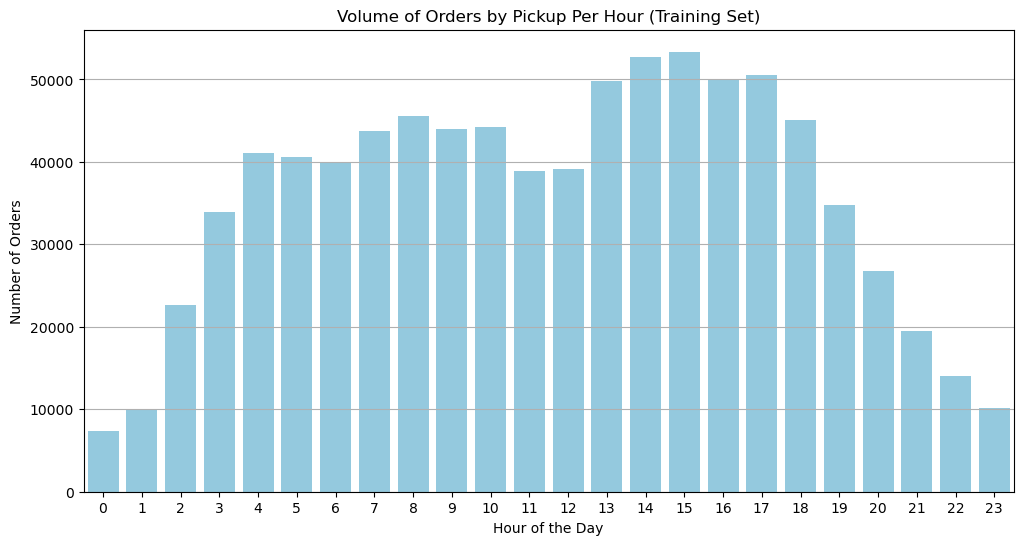

In [14]:
# Calculate the order volume per hour in the training set
train_order_volume = x_train['pickup_hour'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=train_order_volume.index, y=train_order_volume.values, color='skyblue')
plt.title('Volume of Orders by Pickup Per Hour (Training Set)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

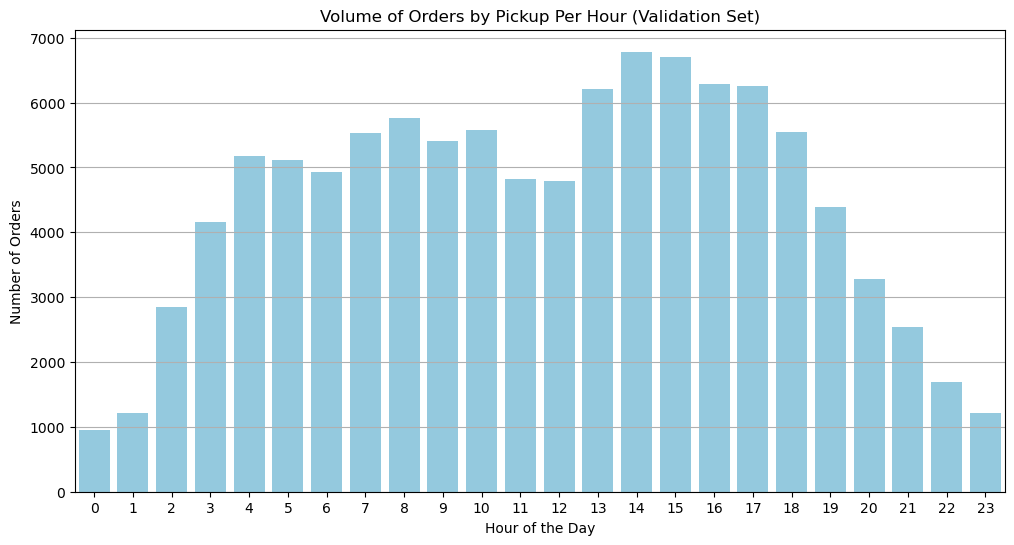

In [15]:
# Calculate the order volume per hour in the validation set
val_order_volume = x_val['pickup_hour'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=val_order_volume.index, y=val_order_volume.values, color='skyblue')
plt.title('Volume of Orders by Pickup Per Hour (Validation Set)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

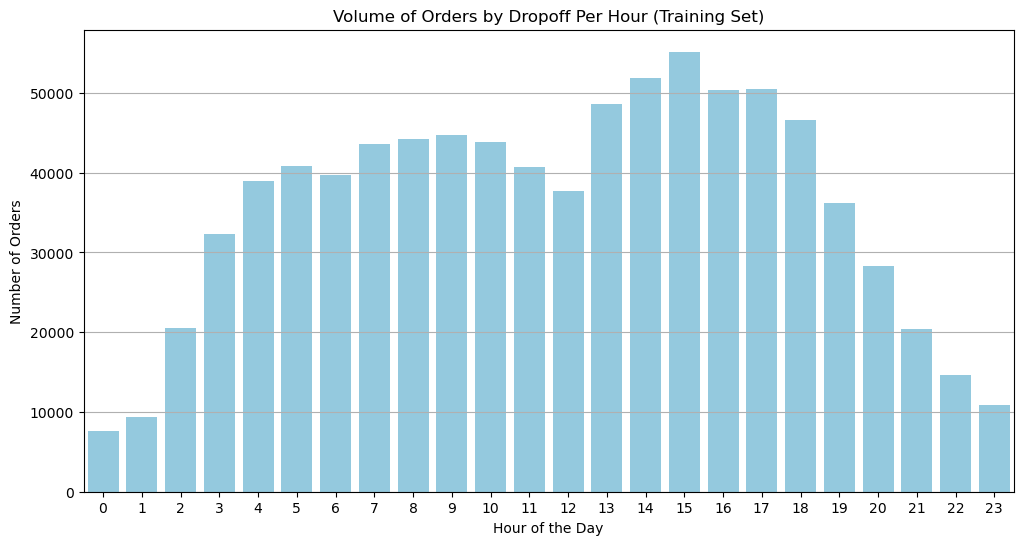

In [16]:
# Calculate the order volume per hour in the training set
train_order_volume = x_train['dropoff_hour'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=train_order_volume.index, y=train_order_volume.values, color='skyblue')
plt.title('Volume of Orders by Dropoff Per Hour (Training Set)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

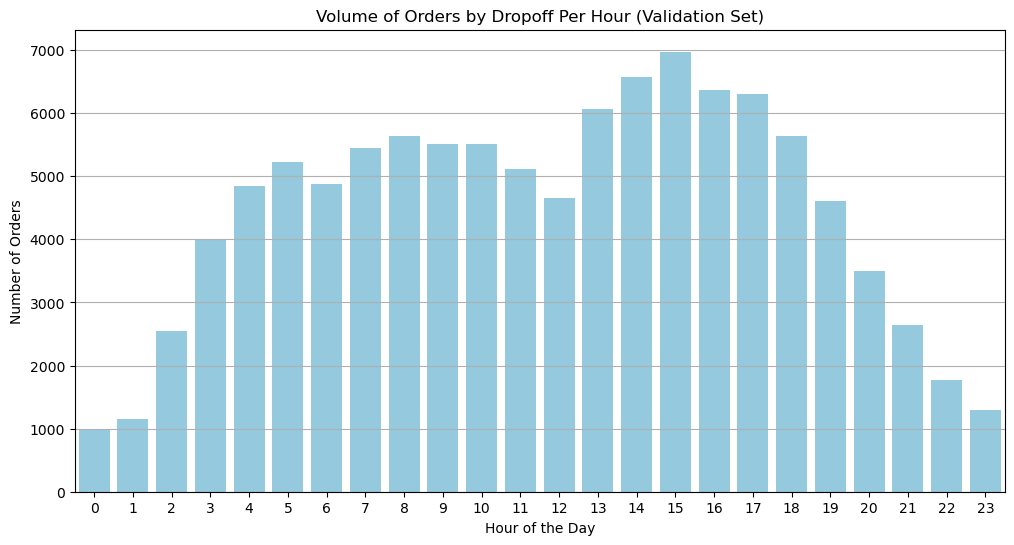

In [17]:
# Calculate the order volume per hour in the training set
val_order_volume = x_val['dropoff_hour'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=val_order_volume.index, y=val_order_volume.values, color='skyblue')
plt.title('Volume of Orders by Dropoff Per Hour (Validation Set)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

#### Vendor ID

Three unique values, which could be conducted one-hot encoding.

In [18]:
print(x_train['vendor_id'].unique())
print(x_val['vendor_id'].unique())
print(x_test['vendor_id'].unique())

['VTS' 'CMT' 'DDS']
['CMT' 'VTS' 'DDS']
['CMT' 'VTS' 'DDS']


#### Rate Code

Summary:
There are some outliers in rate code, hence should be dealt with further.  
We consider the rate range is from 1 to 5.  
For rate less than 1, we consider the customers are not sastified at all, and since this type of outliers is not many, we can replace them by 1.  
For rate larger than 1, we consider the customers are very sastified and since this type of outliers is not many, we can replace them by 5.  
Feature engineering will be conducted further.

In [19]:
# outliers detected
print(x_train['rate_code'].unique())
print(x_val['rate_code'].unique())
print(x_test['rate_code'].unique())

[1.0, NaN, 4.0, 2.0, 5.0, 0.0, 3.0, 6.0]
Categories (7, float64): [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
[1.0, NaN, 0.0, 4.0, 2.0, 5.0, 3.0, 99.0]
Categories (7, float64): [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 99.0]
[1.0, NaN, 4.0, 5.0, 2.0, 0.0, 3.0]
Categories (6, float64): [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


In [20]:
train_rate_count = x_train['rate_code'].value_counts().sort_index()
val_rate_count = x_val['rate_code'].value_counts().sort_index()
test_rate_count = x_test['rate_code'].value_counts().sort_index()

print(train_rate_count)
print(val_rate_count)
print(test_rate_count)

rate_code
0.0        99
1.0    717525
2.0       294
3.0        42
4.0       919
5.0        73
6.0         5
Name: count, dtype: int64
rate_code
0.0         7
1.0     89616
2.0        43
3.0         4
4.0       117
5.0         8
99.0        1
Name: count, dtype: int64
rate_code
0.0       10
1.0    89762
2.0       42
3.0        3
4.0      118
5.0        6
Name: count, dtype: int64


#### Payment Type

We can regard NA and No are both unknown, and they will be dealt with further in the feature engineering.

In [21]:
# outliers detected
print(sorted(x_train['payment_type'].unique()))
print(sorted(x_val['payment_type'].unique()))
print(sorted(x_test['payment_type'].unique()))

['CAS', 'CRD', 'CRE', 'CSH', 'Cas', 'Cre', 'DIS', 'Dis', 'NA ', 'NOC', 'No ', 'UNK']
['CAS', 'CRD', 'CRE', 'CSH', 'Cas', 'Cre', 'DIS', 'Dis', 'NA ', 'NOC', 'No ', 'UNK']
['CAS', 'CRD', 'CRE', 'CSH', 'Cas', 'Cre', 'DIS', 'Dis', 'NA ', 'NOC', 'No ', 'UNK']


In [22]:
train_payment_count = x_train['payment_type'].value_counts().sort_index()
val_payment_count = x_val['payment_type'].value_counts().sort_index()
test_payment_count = x_test['payment_type'].value_counts().sort_index()

print(train_payment_count)
print(val_payment_count)
print(test_payment_count)

payment_type
CAS     26458
CRD    347819
CRE      2291
CSH    436081
Cas     21619
Cre     21125
DIS       228
Dis        22
NA         21
NOC       918
No        108
UNK       838
Name: count, dtype: int64
payment_type
CAS     3307
CRD    43553
CRE      268
CSH    54432
Cas     2725
Cre     2643
DIS       29
Dis        4
NA         1
NOC      119
No         6
UNK      104
Name: count, dtype: int64
payment_type
CAS     3332
CRD    43264
CRE      297
CSH    54667
Cas     2702
Cre     2668
DIS       43
Dis        2
NA         1
NOC      105
No        17
UNK       93
Name: count, dtype: int64


### Tip Paid

In [23]:
# no outliers detected
print(x_train['tip_paid'].unique())
print(x_val['tip_paid'].unique())
print(x_test['tip_paid'].unique())

[0 1]
[1 0]
[0 1]


#### Correlation Between Two Targets

The correlation is not markable, therefore, for modeling, we should build model for each target separetely.

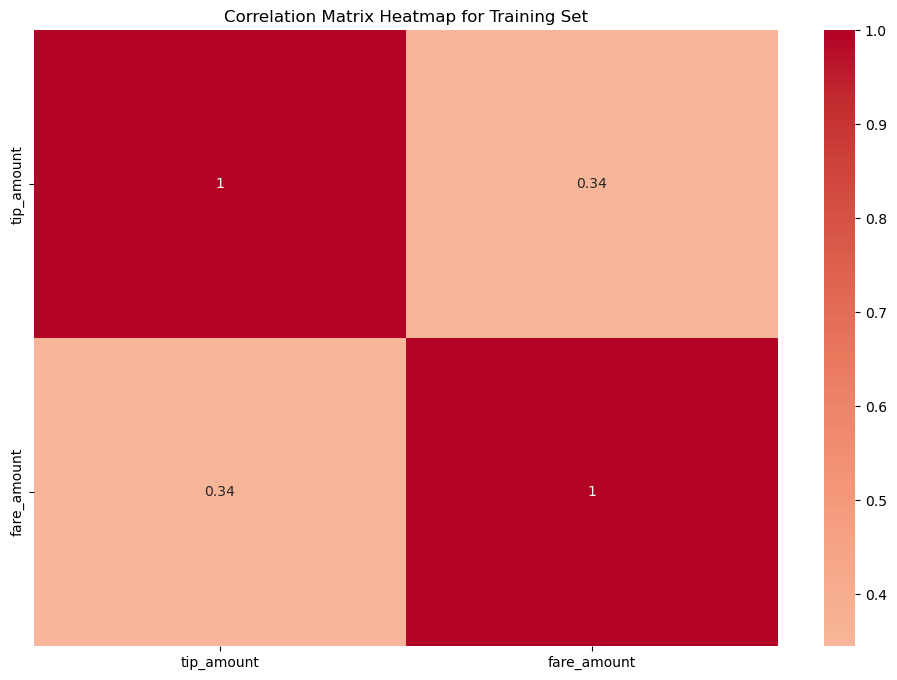

In [24]:
train_correlations = y_train.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(train_correlations, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap for Training Set')
plt.show()

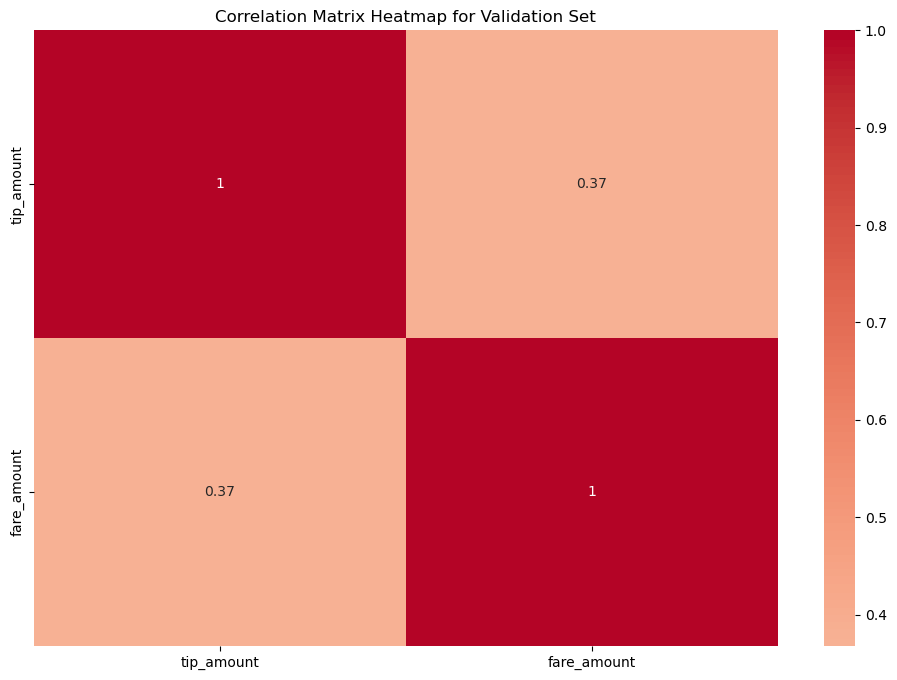

In [25]:
train_correlations = y_val.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(train_correlations, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap for Validation Set')
plt.show()

### Feature Engineering

#### Spatial Features

Summary for Spatial Feature engineering:
1. Mapping the Borough the pickup point and dropoff point belong to
2. Fill missing value of pickup and dropoff by Manhattan
3. One-hot Encoding

In [26]:
pip install geopandas pyogrio shapely

Note: you may need to restart the kernel to use updated packages.


In [27]:
import geopandas as gpd
from shapely.geometry import Point

In [28]:
# # running on google colab
# nyc_shape = gpd.read_file('/content/drive/MyDrive/06 PG/01 SMU/01 Course/02 Track Core/03 CS610 Applied Machine Learning/11 Assignments/02 Assignment 2/NYC Borough Boundaies/NYC_Borough_Boundaries.shp', options={"SHAPE_RESTORE_SHX": "YES"})

# running on local
nyc_shape = gpd.read_file('NYC Borough Boundaies/NYC_Borough_Boundaries.shp', options={"SHAPE_RESTORE_SHX": "YES"})


d:\Anaconda3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option OPTIONS
  return ogr_read(


In [29]:
nyc_shape = nyc_shape[['boroname', 'geometry']]
nyc_shape

,boroname,geometry
0,Staten Island,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,Brooklyn,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."
2,Queens,"MULTIPOLYGON (((-73.82645 40.59053, -73.82642 ..."
3,Manhattan,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,Bronx,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


In [30]:
# training set
## pointing the pickup and drop off longitude and latitude
train_pickup_geometry = [Point(xy) for xy in zip(x_train['pickup_longitude'], x_train['pickup_latitude'])]
train_pickup_gdf = gpd.GeoDataFrame(x_train, geometry=train_pickup_geometry, crs="EPSG:4326") # Set CRS
train_dropoff_geometry =[Point(xy) for xy in zip(x_train['dropoff_longitude'], x_train['dropoff_latitude'])]
train_dropoff_gdf = gpd.GeoDataFrame(x_train, geometry=train_dropoff_geometry, crs="EPSG:4326") # Set CRS
## mapping the borough
train_pickup_borough_join = gpd.sjoin(train_pickup_gdf, nyc_shape, how="left", predicate="within")
train_dropoff_borough_join = gpd.sjoin(train_dropoff_gdf, nyc_shape, how="left", predicate="within")

## create new features
x_train['pickup_borough'] = train_pickup_borough_join['boroname']
x_train['dropoff_borough'] = train_dropoff_borough_join['boroname']

In [31]:
# validation set
val_pickup_geometry = [Point(xy) for xy in zip(x_val['pickup_longitude'], x_val['pickup_latitude'])]
val_pickup_gdf = gpd.GeoDataFrame(x_val, geometry=val_pickup_geometry, crs="EPSG:4326") # Set CRS
val_dropoff_geometry =[Point(xy) for xy in zip(x_val['dropoff_longitude'], x_val['dropoff_latitude'])]
val_dropoff_gdf = gpd.GeoDataFrame(x_val, geometry=val_dropoff_geometry, crs="EPSG:4326") # Set CRS

val_pickup_borough_join = gpd.sjoin(val_pickup_gdf, nyc_shape, how="left", predicate="within")
val_dropoff_borough_join = gpd.sjoin(val_dropoff_gdf, nyc_shape, how="left", predicate="within")

x_val['pickup_borough'] = val_pickup_borough_join['boroname']
x_val['dropoff_borough'] = val_dropoff_borough_join['boroname']

In [32]:
# testing set
test_pickup_geometry = [Point(xy) for xy in zip(x_test['pickup_longitude'], x_test['pickup_latitude'])]
test_pickup_gdf = gpd.GeoDataFrame(x_test, geometry=test_pickup_geometry, crs="EPSG:4326") # Set CRS
test_dropoff_geometry =[Point(xy) for xy in zip(x_test['dropoff_longitude'], x_test['dropoff_latitude'])]
test_dropoff_gdf = gpd.GeoDataFrame(x_test, geometry=test_dropoff_geometry, crs="EPSG:4326") # Set CRS

test_pickup_borough_join = gpd.sjoin(test_pickup_gdf, nyc_shape, how="left", predicate="within")
test_dropoff_borough_join = gpd.sjoin(test_dropoff_gdf, nyc_shape, how="left", predicate="within")

x_test['pickup_borough'] = test_pickup_borough_join['boroname']
x_test['dropoff_borough'] = test_dropoff_borough_join['boroname']

In [33]:
## a few missing values detected
print("---------Train set----------")
print(x_train.isna().sum())
print("---------Validation set----------")
print(x_val.isna().sum())
print("---------Test set----------")
print(x_test.isna().sum())

---------Train set----------
vendor_id                    0
pickup_datetime              0
dropoff_datetime             0
pickup_longitude             0
pickup_latitude              0
dropoff_longitude            0
dropoff_latitude             0
rate_code               138571
passenger_count              0
trip_distance                0
payment_type                 0
tip_paid                     0
pickup_datetime_est          0
dropoff_datetime_est         0
pickup_day                   0
dropoff_day                  0
pickup_hour                  0
dropoff_hour                 0
pickup_borough             401
dropoff_borough            452
dtype: int64
---------Validation set----------
vendor_id                   0
pickup_datetime             0
dropoff_datetime            0
pickup_longitude            0
pickup_latitude             0
dropoff_longitude           0
dropoff_latitude            0
rate_code               17395
passenger_count             0
trip_distance               0
paym

In [34]:
# Manhattan dominates and the missing values are quite a few.
# fill the missing values with Manhattan is accepted
print(x_train['pickup_borough'].value_counts())
print(x_val['pickup_borough'].value_counts())
print(x_test['pickup_borough'].value_counts())

pickup_borough
Manhattan    841023
Queens         8645
Brooklyn       7459
Name: count, dtype: int64
pickup_borough
Manhattan    105146
Queens         1053
Brooklyn        935
Name: count, dtype: int64
pickup_borough
Manhattan    105180
Queens         1013
Brooklyn        934
Name: count, dtype: int64


In [35]:
# fill missing values
x_train['pickup_borough'].fillna('Manhattan', inplace=True)
x_val['pickup_borough'].fillna('Manhattan', inplace=True)
x_test['pickup_borough'].fillna('Manhattan', inplace=True)

C:\Users\Ivan NG\AppData\Local\Temp\ipykernel_5380\3180266184.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['pickup_borough'].fillna('Manhattan', inplace=True)
C:\Users\Ivan NG\AppData\Local\Temp\ipykernel_5380\3180266184.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [36]:
## a few missing values detected
print("---------Train set----------")
print(x_train.isna().sum())
print("---------Validation set----------")
print(x_val.isna().sum())
print("---------Test set----------")
print(x_test.isna().sum())

---------Train set----------
vendor_id                    0
pickup_datetime              0
dropoff_datetime             0
pickup_longitude             0
pickup_latitude              0
dropoff_longitude            0
dropoff_latitude             0
rate_code               138571
passenger_count              0
trip_distance                0
payment_type                 0
tip_paid                     0
pickup_datetime_est          0
dropoff_datetime_est         0
pickup_day                   0
dropoff_day                  0
pickup_hour                  0
dropoff_hour                 0
pickup_borough               0
dropoff_borough            452
dtype: int64
---------Validation set----------
vendor_id                   0
pickup_datetime             0
dropoff_datetime            0
pickup_longitude            0
pickup_latitude             0
dropoff_longitude           0
dropoff_latitude            0
rate_code               17395
passenger_count             0
trip_distance               0
paym

In [37]:
# Manhattan dominates and the missing values are quite a few.
# fill the missing values with Manhattan is accepted
print(x_train['dropoff_borough'].value_counts())
print(x_val['dropoff_borough'].value_counts())
print(x_test['dropoff_borough'].value_counts())

dropoff_borough
Manhattan    823902
Queens        17680
Brooklyn      15492
Bronx             2
Name: count, dtype: int64
dropoff_borough
Manhattan    102975
Queens         2216
Brooklyn       1937
Name: count, dtype: int64
dropoff_borough
Manhattan    102942
Queens         2215
Brooklyn       1972
Bronx             1
Name: count, dtype: int64


In [38]:
# fill missing values
x_train['dropoff_borough'].fillna('Manhattan', inplace=True)
x_val['dropoff_borough'].fillna('Manhattan', inplace=True)
x_test['dropoff_borough'].fillna('Manhattan', inplace=True)

C:\Users\Ivan NG\AppData\Local\Temp\ipykernel_5380\2595634222.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['dropoff_borough'].fillna('Manhattan', inplace=True)
C:\Users\Ivan NG\AppData\Local\Temp\ipykernel_5380\2595634222.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [39]:
## a few missing values detected
print("---------Train set----------")
print(x_train.isna().sum())
print("---------Validation set----------")
print(x_val.isna().sum())
print("---------Test set----------")
print(x_test.isna().sum())

---------Train set----------
vendor_id                    0
pickup_datetime              0
dropoff_datetime             0
pickup_longitude             0
pickup_latitude              0
dropoff_longitude            0
dropoff_latitude             0
rate_code               138571
passenger_count              0
trip_distance                0
payment_type                 0
tip_paid                     0
pickup_datetime_est          0
dropoff_datetime_est         0
pickup_day                   0
dropoff_day                  0
pickup_hour                  0
dropoff_hour                 0
pickup_borough               0
dropoff_borough              0
dtype: int64
---------Validation set----------
vendor_id                   0
pickup_datetime             0
dropoff_datetime            0
pickup_longitude            0
pickup_latitude             0
dropoff_longitude           0
dropoff_latitude            0
rate_code               17395
passenger_count             0
trip_distance               0
paym

In [40]:
# One-hot Encoding
# check unique values
print(x_train['pickup_borough'].unique())
print(x_val['pickup_borough'].unique())
print(x_test['pickup_borough'].unique())
print(x_train['dropoff_borough'].unique())
print(x_val['dropoff_borough'].unique())
print(x_test['dropoff_borough'].unique())
# nyc have five boroughs
nyc_boroughs = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'Staten Island']
# training set
x_train_pickup_borough = x_train[['pickup_borough']]
x_train_dropoff_borough = x_train[['dropoff_borough']]
x_train_pickup_encoder = sklearn.preprocessing.OneHotEncoder(categories = [nyc_boroughs], handle_unknown='ignore', sparse_output=False)
x_train_dropoff_encoder = sklearn.preprocessing.OneHotEncoder(categories = [nyc_boroughs],handle_unknown='ignore', sparse_output=False)
x_train_encoded_pickup = x_train_pickup_encoder.fit_transform(x_train_pickup_borough)
x_train_encoded_dropoff = x_train_dropoff_encoder.fit_transform(x_train_dropoff_borough)

x_train_pickup_encoded_cols = x_train_pickup_encoder.get_feature_names_out(['pickup_borough'])
x_train_dropoff_encoded_cols = x_train_dropoff_encoder.get_feature_names_out(['dropoff_borough'])

x_train_encoded_pickup_df = pd.DataFrame(x_train_encoded_pickup, columns=x_train_pickup_encoded_cols, index = x_train.index)
x_train_encoded_dropoff_df = pd.DataFrame(x_train_encoded_dropoff, columns=x_train_dropoff_encoded_cols, index = x_train.index)
# validation set
x_val_pickup_borough = x_val[['pickup_borough']]
x_val_dropoff_borough = x_val[['dropoff_borough']]
x_val_pickup_encoder = sklearn.preprocessing.OneHotEncoder(categories = [nyc_boroughs], handle_unknown='ignore', sparse_output=False)
x_val_dropoff_encoder = sklearn.preprocessing.OneHotEncoder(categories = [nyc_boroughs],handle_unknown='ignore', sparse_output=False)
x_val_encoded_pickup = x_val_pickup_encoder.fit_transform(x_val_pickup_borough)
x_val_encoded_dropoff = x_val_dropoff_encoder.fit_transform(x_val_dropoff_borough)

x_val_pickup_encoded_cols = x_val_pickup_encoder.get_feature_names_out(['pickup_borough'])
x_val_dropoff_encoded_cols = x_val_dropoff_encoder.get_feature_names_out(['dropoff_borough'])

x_val_encoded_pickup_df = pd.DataFrame(x_val_encoded_pickup, columns=x_val_pickup_encoded_cols, index = x_val.index)
x_val_encoded_dropoff_df = pd.DataFrame(x_val_encoded_dropoff, columns=x_val_dropoff_encoded_cols, index = x_val.index)
# testing set
x_test_pickup_borough = x_test[['pickup_borough']]
x_test_dropoff_borough = x_test[['dropoff_borough']]
x_test_pickup_encoder = sklearn.preprocessing.OneHotEncoder(categories = [nyc_boroughs], handle_unknown='ignore', sparse_output=False)
x_test_dropoff_encoder = sklearn.preprocessing.OneHotEncoder(categories = [nyc_boroughs],handle_unknown='ignore', sparse_output=False)
x_test_encoded_pickup = x_test_pickup_encoder.fit_transform(x_test_pickup_borough)
x_test_encoded_dropoff = x_test_dropoff_encoder.fit_transform(x_test_dropoff_borough)

x_test_pickup_encoded_cols = x_test_pickup_encoder.get_feature_names_out(['pickup_borough'])
x_test_dropoff_encoded_cols = x_test_dropoff_encoder.get_feature_names_out(['dropoff_borough'])

x_test_encoded_pickup_df = pd.DataFrame(x_test_encoded_pickup, columns=x_test_pickup_encoded_cols, index = x_test.index)
x_test_encoded_dropoff_df = pd.DataFrame(x_test_encoded_dropoff, columns=x_test_dropoff_encoded_cols, index = x_test.index)

['Manhattan' 'Queens' 'Brooklyn']
['Manhattan' 'Queens' 'Brooklyn']
['Manhattan' 'Brooklyn' 'Queens']
['Manhattan' 'Brooklyn' 'Queens' 'Bronx']
['Manhattan' 'Queens' 'Brooklyn']
['Manhattan' 'Queens' 'Brooklyn' 'Bronx']


In [41]:
x_train_processed = x_train.drop(columns=['pickup_borough', 'dropoff_borough', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'])
x_val_processed = x_val.drop(columns=['pickup_borough', 'dropoff_borough', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'])
x_test_processed = x_test.drop(columns=['pickup_borough', 'dropoff_borough', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'])

x_train_spatial_dealt = pd.concat([x_train_processed, x_train_encoded_pickup_df, x_train_encoded_dropoff_df], axis=1)
x_val_spatial_dealt = pd.concat([x_val_processed, x_val_encoded_pickup_df, x_val_encoded_dropoff_df], axis=1)
x_test_spatial_dealt = pd.concat([x_test_processed, x_test_encoded_pickup_df, x_test_encoded_dropoff_df], axis=1)

#### Date and Time Features

Summary of feature engineering:
1. bucketise the pick-up and drop-off hour into periods: Morning, Afternoon, Evening and Midnight
2. calculate the travel duration (seconds) by dropoff time - pickup time

In [42]:
# this is according to the common knowledge
def is_weekday(day):
    if day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']:
        return 1
    else:
        return 0

In [43]:
x_train_spatial_dealt['pickup_isweekday'] = x_train_spatial_dealt['pickup_day'].apply(is_weekday)
x_val_spatial_dealt['pickup_isweekday'] = x_val_spatial_dealt['pickup_day'].apply(is_weekday)
x_test_spatial_dealt['pickup_isweekday'] = x_test_spatial_dealt['pickup_day'].apply(is_weekday)

x_train_spatial_dealt['dropoff_isweekday'] = x_train_spatial_dealt['dropoff_day'].apply(is_weekday)
x_val_spatial_dealt['dropoff_isweekday'] = x_val_spatial_dealt['dropoff_day'].apply(is_weekday)
x_test_spatial_dealt['dropoff_isweekday'] = x_test_spatial_dealt['dropoff_day'].apply(is_weekday)

x_train_day_spatial_dealt = x_train_spatial_dealt.drop(columns=['pickup_day', 'dropoff_day'])
x_val_day_spatial_dealt = x_val_spatial_dealt.drop(columns=['pickup_day', 'dropoff_day'])
x_test_day_spatial_dealt = x_test_spatial_dealt.drop(columns=['pickup_day', 'dropoff_day'])

In [44]:
x_train_day_spatial_dealt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 857528 entries, 234510 to 1006142
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype                     
---  ------                         --------------   -----                     
 0   vendor_id                      857528 non-null  object                    
 1   pickup_datetime                857528 non-null  object                    
 2   dropoff_datetime               857528 non-null  object                    
 3   rate_code                      718957 non-null  category                  
 4   passenger_count                857528 non-null  int64                     
 5   trip_distance                  857528 non-null  float64                   
 6   payment_type                   857528 non-null  object                    
 7   tip_paid                       857528 non-null  int64                     
 8   pickup_datetime_est            857528 non-null  datetime64[ns, US/Eastern]
 9   dro

In [45]:
# this is according to the common knowledge
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Midnight'

In [46]:
x_train_day_spatial_dealt['pickup_period'] = x_train_day_spatial_dealt['pickup_hour'].apply(get_time_of_day)
x_train_day_spatial_dealt['dropoff_period'] = x_train_day_spatial_dealt['dropoff_hour'].apply(get_time_of_day)

x_val_day_spatial_dealt['pickup_period'] = x_val_day_spatial_dealt['pickup_hour'].apply(get_time_of_day)
x_val_day_spatial_dealt['dropoff_period'] = x_val_day_spatial_dealt['dropoff_hour'].apply(get_time_of_day)

x_test_day_spatial_dealt['pickup_period'] = x_test_day_spatial_dealt['pickup_hour'].apply(get_time_of_day)
x_test_day_spatial_dealt['dropoff_period'] = x_test_day_spatial_dealt['dropoff_hour'].apply(get_time_of_day)

In [47]:
# one-hot encoding
period_type = ['Morning', 'Afternoon', 'Evening', 'Midnight']

# training set
x_train_pickup_period = x_train_day_spatial_dealt[['pickup_period']]
x_train_dropoff_period = x_train_day_spatial_dealt[['dropoff_period']]
x_train_pickup_period_encoder = sklearn.preprocessing.OneHotEncoder(categories = [period_type], handle_unknown='ignore', sparse_output=False)
x_train_dropoff_period_encoder = sklearn.preprocessing.OneHotEncoder(categories = [period_type],handle_unknown='ignore', sparse_output=False)
x_train_encoded_pickup_period = x_train_pickup_period_encoder.fit_transform(x_train_pickup_period)
x_train_encoded_dropoff_period = x_train_dropoff_period_encoder.fit_transform(x_train_dropoff_period)

x_train_pickup_period_encoded_cols = x_train_pickup_period_encoder.get_feature_names_out(['pickup_period'])
x_train_dropoff_period_encoded_cols = x_train_dropoff_period_encoder.get_feature_names_out(['dropoff_period'])

x_train_encoded_pickup_period_df = pd.DataFrame(x_train_encoded_pickup_period, columns=x_train_pickup_period_encoded_cols, index = x_train_day_spatial_dealt.index)
x_train_encoded_dropoff_period_df = pd.DataFrame(x_train_encoded_dropoff_period, columns=x_train_dropoff_period_encoded_cols, index = x_train_day_spatial_dealt.index)

# validation set
x_val_pickup_period = x_val_day_spatial_dealt[['pickup_period']]
x_val_dropoff_period = x_val_day_spatial_dealt[['dropoff_period']]
x_val_pickup_period_encoder = sklearn.preprocessing.OneHotEncoder(categories = [period_type], handle_unknown='ignore', sparse_output=False)
x_val_dropoff_period_encoder = sklearn.preprocessing.OneHotEncoder(categories = [period_type],handle_unknown='ignore', sparse_output=False)
x_val_encoded_pickup_period = x_val_pickup_period_encoder.fit_transform(x_val_pickup_period)
x_val_encoded_dropoff_period = x_val_dropoff_period_encoder.fit_transform(x_val_dropoff_period)

x_val_pickup_period_encoded_cols = x_val_pickup_period_encoder.get_feature_names_out(['pickup_period'])
x_val_dropoff_period_encoded_cols = x_val_dropoff_period_encoder.get_feature_names_out(['dropoff_period'])

x_val_encoded_pickup_period_df = pd.DataFrame(x_val_encoded_pickup_period, columns=x_val_pickup_period_encoded_cols, index = x_val_day_spatial_dealt.index)
x_val_encoded_dropoff_period_df = pd.DataFrame(x_val_encoded_dropoff_period, columns=x_val_dropoff_period_encoded_cols, index = x_val_day_spatial_dealt.index)

# testing set
x_test_pickup_period = x_test_day_spatial_dealt[['pickup_period']]
x_test_dropoff_period = x_test_day_spatial_dealt[['dropoff_period']]
x_test_pickup_period_encoder = sklearn.preprocessing.OneHotEncoder(categories = [period_type], handle_unknown='ignore', sparse_output=False)
x_test_dropoff_period_encoder = sklearn.preprocessing.OneHotEncoder(categories = [period_type],handle_unknown='ignore', sparse_output=False)
x_test_encoded_pickup_period = x_test_pickup_period_encoder.fit_transform(x_test_pickup_period)
x_test_encoded_dropoff_period = x_test_dropoff_period_encoder.fit_transform(x_test_dropoff_period)

x_test_pickup_period_encoded_cols = x_test_pickup_period_encoder.get_feature_names_out(['pickup_period'])
x_test_dropoff_period_encoded_cols = x_test_dropoff_period_encoder.get_feature_names_out(['dropoff_period'])

x_test_encoded_pickup_period_df = pd.DataFrame(x_test_encoded_pickup_period, columns=x_test_pickup_period_encoded_cols, index = x_test_day_spatial_dealt.index)
x_test_encoded_dropoff_period_df = pd.DataFrame(x_test_encoded_dropoff_period, columns=x_test_dropoff_period_encoded_cols, index = x_test_day_spatial_dealt.index)

In [48]:
x_train_processed_3 = x_train_day_spatial_dealt.drop(columns=['pickup_hour', "dropoff_hour", "pickup_period", "dropoff_period"])
x_val_processed_3 = x_val_day_spatial_dealt.drop(columns=['pickup_hour', "dropoff_hour","pickup_period", "dropoff_period"])
x_test_processed_3 = x_test_day_spatial_dealt.drop(columns=['pickup_hour', "dropoff_hour", "pickup_period", "dropoff_period"])

x_train_day_spatial_dealt2 = pd.concat([x_train_processed_3, x_train_encoded_pickup_period_df, x_train_encoded_dropoff_period_df], axis=1)
x_val_day_spatial_dealt2 = pd.concat([x_val_processed_3, x_val_encoded_pickup_period_df, x_val_encoded_dropoff_period_df], axis=1)
x_test_day_spatial_dealt2 = pd.concat([x_test_processed_3, x_test_encoded_pickup_period_df, x_test_encoded_dropoff_period_df], axis=1)

In [49]:
## travel_duration
x_train_day_spatial_dealt2['travel_duration'] = (x_train_day_spatial_dealt['dropoff_datetime_est'] - x_train_day_spatial_dealt2['pickup_datetime_est']).dt.total_seconds()
x_val_day_spatial_dealt2['travel_duration'] = (x_val_day_spatial_dealt2['dropoff_datetime_est'] - x_val_day_spatial_dealt2['pickup_datetime_est']).dt.total_seconds()
x_test_day_spatial_dealt2['travel_duration'] = (x_test_day_spatial_dealt2['dropoff_datetime_est'] - x_test_day_spatial_dealt2['pickup_datetime_est']).dt.total_seconds()

In [50]:
x_train_dt_spatial_dealt = x_train_day_spatial_dealt2.drop(columns=['pickup_datetime','dropoff_datetime','pickup_datetime_est', 'dropoff_datetime_est'])
x_val_dt_spatial_dealt = x_val_day_spatial_dealt2.drop(columns=['pickup_datetime','dropoff_datetime','pickup_datetime_est', 'dropoff_datetime_est'])
x_test_dt_spatial_dealt = x_test_day_spatial_dealt2.drop(columns=['pickup_datetime','dropoff_datetime','pickup_datetime_est', 'dropoff_datetime_est'])

In [51]:
## no mssing values about date related features
print("---------Train set----------")
print(x_train_dt_spatial_dealt.isna().sum())
print("---------Validation set----------")
print(x_val_dt_spatial_dealt.isna().sum())
print("---------Test set----------")
print(x_test_dt_spatial_dealt.isna().sum())

---------Train set----------
vendor_id                             0
rate_code                        138571
passenger_count                       0
trip_distance                         0
payment_type                          0
tip_paid                              0
pickup_borough_Manhattan              0
pickup_borough_Queens                 0
pickup_borough_Brooklyn               0
pickup_borough_Bronx                  0
pickup_borough_Staten Island          0
dropoff_borough_Manhattan             0
dropoff_borough_Queens                0
dropoff_borough_Brooklyn              0
dropoff_borough_Bronx                 0
dropoff_borough_Staten Island         0
pickup_isweekday                      0
dropoff_isweekday                     0
pickup_period_Morning                 0
pickup_period_Afternoon               0
pickup_period_Evening                 0
pickup_period_Midnight                0
dropoff_period_Morning                0
dropoff_period_Afternoon              0
dropoff_per

#### Vendor ID

In [52]:
print(x_train_dt_spatial_dealt['vendor_id'].unique())
print(x_val_dt_spatial_dealt['vendor_id'].unique())
print(x_test_dt_spatial_dealt['vendor_id'].unique())

['VTS' 'CMT' 'DDS']
['CMT' 'VTS' 'DDS']
['CMT' 'VTS' 'DDS']


In [53]:
# one-hot encoding
vendors = ['VTS','CMT','DDS']

# training set
x_train_vendor = x_train_dt_spatial_dealt[['vendor_id']]
x_train_vendor_encoder = sklearn.preprocessing.OneHotEncoder(categories = [vendors], handle_unknown='ignore', sparse_output=False)
x_train_encoded_vendor = x_train_vendor_encoder.fit_transform(x_train_vendor)

x_train_vendor_encoded_cols = x_train_vendor_encoder.get_feature_names_out(['vendor_id'])

x_train_encoded_vendor_df = pd.DataFrame(x_train_encoded_vendor, columns=x_train_vendor_encoded_cols, index = x_train_dt_spatial_dealt.index)

# validation set
x_val_vendor = x_val_dt_spatial_dealt[['vendor_id']]
x_val_vendor_encoder = sklearn.preprocessing.OneHotEncoder(categories = [vendors], handle_unknown='ignore', sparse_output=False)
x_val_encoded_vendor = x_val_vendor_encoder.fit_transform(x_val_vendor)

x_val_vendor_encoded_cols = x_val_vendor_encoder.get_feature_names_out(['vendor_id'])

x_val_encoded_vendor_df = pd.DataFrame(x_val_encoded_vendor, columns=x_val_vendor_encoded_cols, index = x_val_dt_spatial_dealt.index)

# testing set
x_test_vendor = x_test_dt_spatial_dealt[['vendor_id']]
x_test_vendor_encoder = sklearn.preprocessing.OneHotEncoder(categories = [vendors], handle_unknown='ignore', sparse_output=False)
x_test_encoded_vendor = x_test_vendor_encoder.fit_transform(x_test_vendor)

x_test_vendor_encoded_cols = x_test_vendor_encoder.get_feature_names_out(['vendor_id'])

x_test_encoded_vendor_df = pd.DataFrame(x_test_encoded_vendor, columns=x_test_vendor_encoded_cols, index = x_test_dt_spatial_dealt.index)

In [54]:
x_train_processed_4 = x_train_dt_spatial_dealt.drop(columns=['vendor_id'])
x_val_processed_4 = x_val_dt_spatial_dealt.drop(columns=['vendor_id'])
x_test_processed_4 = x_test_dt_spatial_dealt.drop(columns=['vendor_id'])

x_train_day_spatial_vendor_dealt = pd.concat([x_train_processed_4, x_train_encoded_vendor_df], axis=1)
x_val_day_spatial_vendor_dealt = pd.concat([x_val_processed_4, x_val_encoded_vendor_df], axis=1)
x_test_day_spatial_vendor_dealt = pd.concat([x_test_processed_4, x_test_encoded_vendor_df], axis=1)

In [55]:
## no mssing values
print("---------Train set----------")
print(x_train_day_spatial_vendor_dealt.isna().sum())
print("---------Validation set----------")
print(x_val_day_spatial_vendor_dealt.isna().sum())
print("---------Test set----------")
print(x_test_day_spatial_vendor_dealt.isna().sum())

---------Train set----------
rate_code                        138571
passenger_count                       0
trip_distance                         0
payment_type                          0
tip_paid                              0
pickup_borough_Manhattan              0
pickup_borough_Queens                 0
pickup_borough_Brooklyn               0
pickup_borough_Bronx                  0
pickup_borough_Staten Island          0
dropoff_borough_Manhattan             0
dropoff_borough_Queens                0
dropoff_borough_Brooklyn              0
dropoff_borough_Bronx                 0
dropoff_borough_Staten Island         0
pickup_isweekday                      0
dropoff_isweekday                     0
pickup_period_Morning                 0
pickup_period_Afternoon               0
pickup_period_Evening                 0
pickup_period_Midnight                0
dropoff_period_Morning                0
dropoff_period_Afternoon              0
dropoff_period_Evening                0
dropoff_per

#### Payment Type

In [56]:
print(x_train_day_spatial_vendor_dealt['payment_type'].unique())
print(x_val_day_spatial_vendor_dealt['payment_type'].unique())
print(x_test_day_spatial_vendor_dealt['payment_type'].unique())

['CSH' 'CRD' 'Cas' 'Cre' 'CRE' 'CAS' 'NOC' 'UNK' 'DIS' 'No ' 'NA ' 'Dis']
['CRD' 'CSH' 'Cre' 'CAS' 'Cas' 'CRE' 'NOC' 'DIS' 'UNK' 'Dis' 'No ' 'NA ']
['CSH' 'CRD' 'Cre' 'Cas' 'CAS' 'NOC' 'UNK' 'CRE' 'DIS' 'No ' 'Dis' 'NA ']


In [57]:
x_train_day_spatial_vendor_dealt['payment_type'] = x_train_day_spatial_vendor_dealt['payment_type'].str.upper()
x_val_day_spatial_vendor_dealt['payment_type'] = x_val_day_spatial_vendor_dealt['payment_type'].str.upper()
x_test_day_spatial_vendor_dealt['payment_type'] = x_test_day_spatial_vendor_dealt['payment_type'].str.upper()

In [58]:
print(x_train_day_spatial_vendor_dealt['payment_type'].unique())
print(x_val_day_spatial_vendor_dealt['payment_type'].unique())
print(x_test_day_spatial_vendor_dealt['payment_type'].unique())

['CSH' 'CRD' 'CAS' 'CRE' 'NOC' 'UNK' 'DIS' 'NO ' 'NA ']
['CRD' 'CSH' 'CRE' 'CAS' 'NOC' 'DIS' 'UNK' 'NO ' 'NA ']
['CSH' 'CRD' 'CRE' 'CAS' 'NOC' 'UNK' 'DIS' 'NO ' 'NA ']


In [59]:
# one-hot encoding
payment_type = ['CSH', 'CRD','CAS','CRE','NOC','UNK','DIS']

# training set
x_train_payment = x_train_day_spatial_vendor_dealt[['payment_type']]
x_train_payment_encoder = sklearn.preprocessing.OneHotEncoder(categories = [payment_type], handle_unknown='ignore', sparse_output=False)
x_train_encoded_payment = x_train_payment_encoder.fit_transform(x_train_payment)

x_train_payment_encoded_cols = x_train_payment_encoder.get_feature_names_out(['payment_type'])

x_train_encoded_payment_df = pd.DataFrame(x_train_encoded_payment, columns=x_train_payment_encoded_cols, index = x_train_day_spatial_vendor_dealt.index)

# validation set
x_val_payment = x_val_day_spatial_vendor_dealt[['payment_type']]
x_val_payment_encoder = sklearn.preprocessing.OneHotEncoder(categories = [payment_type], handle_unknown='ignore', sparse_output=False)
x_val_encoded_payment = x_val_payment_encoder.fit_transform(x_val_payment)

x_val_payment_encoded_cols = x_val_payment_encoder.get_feature_names_out(['payment_type'])

x_val_encoded_payment_df = pd.DataFrame(x_val_encoded_payment, columns=x_val_payment_encoded_cols, index = x_val_day_spatial_vendor_dealt.index)

# testing set
x_test_payment = x_test_day_spatial_vendor_dealt[['payment_type']]
x_test_payment_encoder = sklearn.preprocessing.OneHotEncoder(categories = [payment_type], handle_unknown='ignore', sparse_output=False)
x_test_encoded_payment = x_test_payment_encoder.fit_transform(x_test_payment)

x_test_payment_encoded_cols = x_test_payment_encoder.get_feature_names_out(['payment_type'])

x_test_encoded_payment_df = pd.DataFrame(x_test_encoded_payment, columns=x_test_payment_encoded_cols, index = x_test_day_spatial_vendor_dealt.index)

In [60]:
x_train_processed_5 = x_train_day_spatial_vendor_dealt.drop(columns=['payment_type'])
x_val_processed_5 = x_val_day_spatial_vendor_dealt.drop(columns=['payment_type'])
x_test_processed_5 = x_test_day_spatial_vendor_dealt.drop(columns=['payment_type'])

x_train_day_spatial_vendor_payment_dealt = pd.concat([x_train_processed_5, x_train_encoded_payment_df], axis=1)
x_val_day_spatial_vendor_payment_dealt = pd.concat([x_val_processed_5, x_val_encoded_payment_df], axis=1)
x_test_day_spatial_vendor_payment_dealt = pd.concat([x_test_processed_5, x_test_encoded_payment_df], axis=1)

In [61]:
## no mssing values
print("---------Train set----------")
print(x_train_day_spatial_vendor_payment_dealt.isna().sum())
print("---------Validation set----------")
print(x_val_day_spatial_vendor_payment_dealt.isna().sum())
print("---------Test set----------")
print(x_test_day_spatial_vendor_payment_dealt.isna().sum())

---------Train set----------
rate_code                        138571
passenger_count                       0
trip_distance                         0
tip_paid                              0
pickup_borough_Manhattan              0
pickup_borough_Queens                 0
pickup_borough_Brooklyn               0
pickup_borough_Bronx                  0
pickup_borough_Staten Island          0
dropoff_borough_Manhattan             0
dropoff_borough_Queens                0
dropoff_borough_Brooklyn              0
dropoff_borough_Bronx                 0
dropoff_borough_Staten Island         0
pickup_isweekday                      0
dropoff_isweekday                     0
pickup_period_Morning                 0
pickup_period_Afternoon               0
pickup_period_Evening                 0
pickup_period_Midnight                0
dropoff_period_Morning                0
dropoff_period_Afternoon              0
dropoff_period_Evening                0
dropoff_period_Midnight               0
travel_dura

#### Rate Code

In [79]:
print(x_train_day_spatial_vendor_payment_dealt['rate_code'].unique())
print(x_val_day_spatial_vendor_payment_dealt['rate_code'].unique())
print(x_test_day_spatial_vendor_payment_dealt['rate_code'].unique())

[ 1. nan  4.  2.  5.  3.]
[ 1. nan  4.  2.  5.  3.]
[ 1. nan  4.  5.  2.  3.]


In [80]:
x_train_day_spatial_vendor_payment_dealt['rate_code'].isna().sum()/x_train_day_spatial_vendor_payment_dealt.shape[0]

0.16159355729492214

In [81]:
def rate_code_mapping(rate_code):
  if np.isnan(rate_code):
      return 0
  elif rate_code > 5:
      return 5
  elif rate_code < 1:
      return 1
  else:
      return rate_code

In [82]:
x_train_day_spatial_vendor_payment_dealt['rate_code'] = x_train_day_spatial_vendor_payment_dealt['rate_code'].apply(rate_code_mapping)
x_val_day_spatial_vendor_payment_dealt['rate_code'] = x_val_day_spatial_vendor_payment_dealt['rate_code'].apply(rate_code_mapping)
x_test_day_spatial_vendor_payment_dealt['rate_code'] = x_test_day_spatial_vendor_payment_dealt['rate_code'].apply(rate_code_mapping)

In [83]:
## no mssing values
print("---------Train set----------")
print(x_train_day_spatial_vendor_payment_dealt.isna().sum())
print("---------Validation set----------")
print(x_train_day_spatial_vendor_payment_dealt.isna().sum())
print("---------Test set----------")
print(x_train_day_spatial_vendor_payment_dealt.isna().sum())

---------Train set----------
rate_code                        0
passenger_count                  0
trip_distance                    0
tip_paid                         0
pickup_borough_Manhattan         0
pickup_borough_Queens            0
pickup_borough_Brooklyn          0
pickup_borough_Bronx             0
pickup_borough_Staten Island     0
dropoff_borough_Manhattan        0
dropoff_borough_Queens           0
dropoff_borough_Brooklyn         0
dropoff_borough_Bronx            0
dropoff_borough_Staten Island    0
pickup_isweekday                 0
dropoff_isweekday                0
pickup_period_Morning            0
pickup_period_Afternoon          0
pickup_period_Evening            0
pickup_period_Midnight           0
dropoff_period_Morning           0
dropoff_period_Afternoon         0
dropoff_period_Evening           0
dropoff_period_Midnight          0
travel_duration                  0
vendor_id_VTS                    0
vendor_id_CMT                    0
vendor_id_DDS             

In [84]:
x_train_final = x_train_day_spatial_vendor_payment_dealt.copy()
x_val_final = x_val_day_spatial_vendor_payment_dealt.copy()
x_test_final = x_test_day_spatial_vendor_payment_dealt.copy()

In [85]:
x_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 857528 entries, 234510 to 1006142
Data columns (total 35 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   rate_code                      857528 non-null  float64
 1   passenger_count                857528 non-null  int64  
 2   trip_distance                  857528 non-null  float64
 3   tip_paid                       857528 non-null  int64  
 4   pickup_borough_Manhattan       857528 non-null  float64
 5   pickup_borough_Queens          857528 non-null  float64
 6   pickup_borough_Brooklyn        857528 non-null  float64
 7   pickup_borough_Bronx           857528 non-null  float64
 8   pickup_borough_Staten Island   857528 non-null  float64
 9   dropoff_borough_Manhattan      857528 non-null  float64
 10  dropoff_borough_Queens         857528 non-null  float64
 11  dropoff_borough_Brooklyn       857528 non-null  float64
 12  dropoff_borough_Bronx        

### Check Correlation of Two Targets

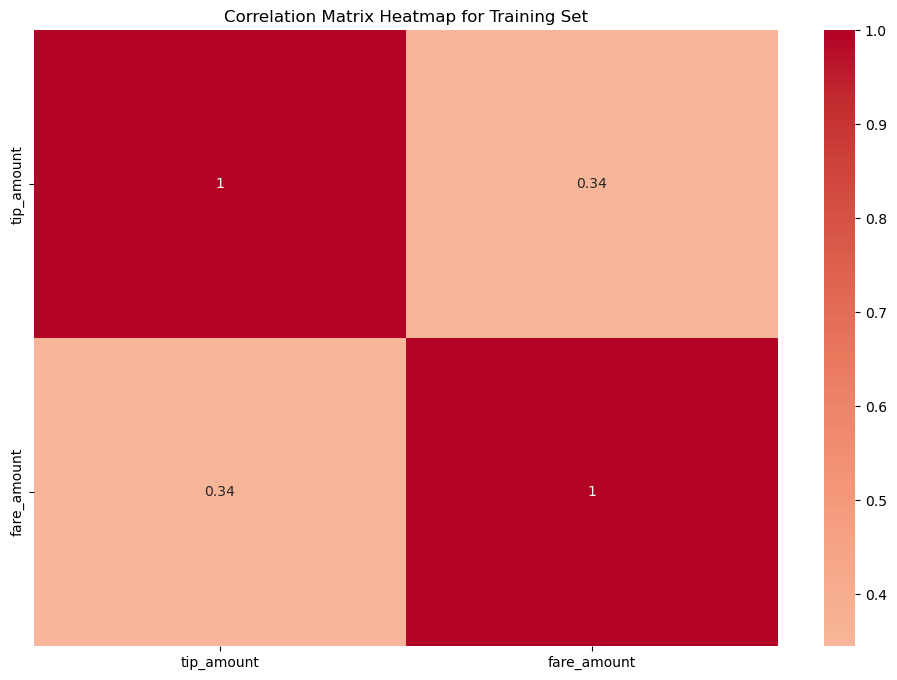

In [69]:
train_correlations = y_train.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(train_correlations, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap for Training Set')
plt.show()

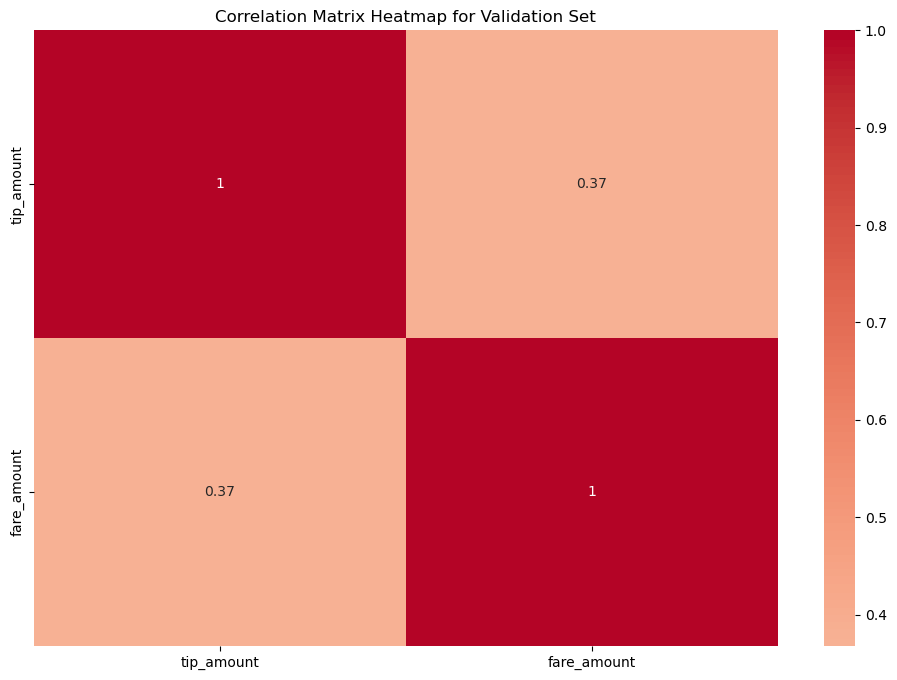

In [70]:
validation_correlations = y_val.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(validation_correlations, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap for Validation Set')
plt.show()

### Modeling

In [87]:
y_train_tipamount = y_train['tip_amount']
y_val_tipamount = y_val['fare_amount']
y_test_tipamount = y_test['fare_amount']

#### Random Forest: Tip Amount

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint


# Define the parameter distribution for Random Search
param_dist = {
    'n_estimators': randint(10, 200),  # Number of trees in the forest
    'max_depth': randint(5, 30),       # Maximum depth of the tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10)   # Minimum number of samples required to be at a leaf node
}

# Create a Random Forest Regressor model
rf = RandomForestRegressor(random_state=42)

# Create RandomizedSearchCV object
# n_iter: Number of parameter settings that are sampled. Trade-off between computation time and improvement
# cv: Number of folds for cross-validation
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=10, cv=3, scoring='neg_mean_squared_error',
                                   random_state=42, n_jobs=-1, verbose= 2, pre_dispatch='2*n_jobs')

# Fit RandomizedSearchCV to the training data
random_search.fit(x_train_final, y_train_tipamount)


# You can now use the best estimator found by RandomizedSearchCV for further analysis or prediction
best_rf_model_tipamount = random_search.best_estimator_

# Evaluate the best model on the validation set (optional)
from sklearn.metrics import mean_squared_error
y_val_tipamount_pred = best_rf_model_tipamount.predict(x_val_final)
mse_val_tipamount = mean_squared_error(y_val_tipamount, y_val_tipamount_pred)
print("Mean Squared Error on validation set (Tip Amount):", mse_val_tipamount)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


d:\Anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters found: {'max_depth': 11, 'min_samples_leaf': 4, 'min_samples_split': 16, 'n_estimators': 116}
Best negative mean squared error: nan
Mean Squared Error on validation set (Tip Amount): 72.71577991311365


In [115]:
# RMSE Check
## Training Set
y_train_pred_tipamount = best_rf_model_tipamount.predict(x_train_final)
rmse_train_tipamount = np.sqrt(mean_squared_error(y_train['fare_amount'], y_train_pred_tipamount))

print(f"RMSE on training set for tip_amount: {rmse_train_tipamount}")

## Validation Set
y_val_pred_tipamount = best_rf_model_tipamount.predict(x_val_final)
rmse_val_tipamount = np.sqrt(mean_squared_error(y_val['tip_amount'], y_val_pred_tipamount))

print(f"RMSE on validation set for tip_amount: {rmse_val_tipamount}")

# Testing Data Set
y_test_pred_tipamount = best_rf_model_tipamount.predict(x_test_final)
rmse_test_tipamount = np.sqrt(mean_squared_error(y_test['fare_amount'], y_test_pred_tipamount))

print(f"RMSE on testing set for tip_amount: {rmse_test_tipamount}")

# Feature Importance
feature_importances_tipamount = best_rf_model_tipamount.feature_importances_
feature_names = x_train_final.columns

importance_df_tipamount = pd.DataFrame({'Feature': feature_names, 'Importance_Tip_Amount': feature_importances_tipamount})
importance_df_tipamount = importance_df_tipamount.sort_values('Importance_Tip_Amount', ascending=False)

print("\nFeature Importances for Tip Amount:")
print(importance_df_tipamount)

# Parameters
parameters_dict_tipamount = best_rf_model_tipamount.get_params()
parameters_tipamount = pd.DataFrame(list(parameters_dict_tipamount.items()), columns=['Parameter', 'Value'])
print("\nParameters for Best Model:")
print(parameters_tipamount)

RMSE on training set for tip_amount: 8.539502319445601
RMSE on validation set for tip_amount: 0.5333379516989218
RMSE on testing set for tip_amount: 8.519739126429949

Feature Importances for Tip Amount:
                          Feature  Importance_Tip_Amount
3                        tip_paid               0.806275
24                travel_duration               0.127753
2                   trip_distance               0.044123
0                       rate_code               0.009649
9       dropoff_borough_Manhattan               0.002608
25                  vendor_id_VTS               0.001414
1                 passenger_count               0.001182
23        dropoff_period_Midnight               0.001096
31               payment_type_CRE               0.001023
18          pickup_period_Evening               0.000741
19         pickup_period_Midnight               0.000638
22         dropoff_period_Evening               0.000614
29               payment_type_CRD               0.00038

#### Random Forest: Fare Amount

In [116]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint


y_train_fareamount = y_train['fare_amount']
y_val_fareamount = y_val['fare_amount']
y_test_fareamount = y_test['fare_amount']

# Define the parameter distribution for Random Search
param_dist = {
    'n_estimators': randint(10, 200),  # Number of trees in the forest
    'max_depth': randint(5, 30),       # Maximum depth of the tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10)   # Minimum number of samples required to be at a leaf node
}

# Create a Random Forest Regressor model
rf = RandomForestRegressor(random_state=42)

# Create RandomizedSearchCV object
# n_iter: Number of parameter settings that are sampled. Trade-off between computation time and improvement
# cv: Number of folds for cross-validation
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=10, cv=3, scoring='neg_mean_squared_error',
                                   random_state=42, n_jobs=-1, verbose= 2, pre_dispatch='2*n_jobs')

# Fit RandomizedSearchCV to the training data
random_search.fit(x_train_final, y_train_fareamount)

# Get the best parameters and best score
best_params_fareamount = random_search.best_params_
best_score_fareamount = -random_search.best_score_ # Convert negative MSE to positive MSE

print("Best parameters found:", best_params_fareamount)
print("Best negative mean squared error:", best_score_fareamount)

# You can now use the best estimator found by RandomizedSearchCV for further analysis or prediction
best_rf_model_fareamount = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


d:\Anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1102: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best parameters found: {'max_depth': 11, 'min_samples_leaf': 4, 'min_samples_split': 16, 'n_estimators': 116}
Best negative mean squared error: nan
Mean Squared Error on validation set (Tip Amount): 1.3014531354547287


In [118]:
# Evaluate the best model on the validation set (optional)
from sklearn.metrics import mean_squared_error
y_val_fareamount_pred = best_rf_model_fareamount.predict(x_val_final)
mse_val_fareamount = mean_squared_error(y_val_fareamount, y_val_fareamount_pred)
print("Mean Squared Error on validation set (Fare Amount):", mse_val_fareamount)

Mean Squared Error on validation set (Fare Amount): 1.3014531354547287


In [117]:
# RMSE Check
## Training Set
y_train_pred_fareamount = best_rf_model_fareamount.predict(x_train_final)
rmse_train_fareamount = np.sqrt(mean_squared_error(y_train['fare_amount'], y_train_pred_fareamount))

print(f"RMSE on training set for fare_amount: {rmse_train_fareamount}")

## Validation Set
y_val_pred_fareamount = best_rf_model_fareamount.predict(x_val_final)
rmse_val_fareamount = np.sqrt(mean_squared_error(y_val['tip_amount'], y_val_pred_fareamount))

print(f"RMSE on validation set for fare_amount: {rmse_val_fareamount}")

# Testing Data Set
y_test_pred_fareamount = best_rf_model_fareamount.predict(x_test_final)
rmse_test_fareamount = np.sqrt(mean_squared_error(y_test['fare_amount'], y_test_pred_fareamount))

print(f"RMSE on testing set for fare_amount: {rmse_test_fareamount}")

# Feature Importance
feature_importances_fareamount = best_rf_model_fareamount.feature_importances_
feature_names = x_train_final.columns

importance_df_fareamount = pd.DataFrame({'Feature': feature_names, 'Importance_Fare_Amount': feature_importances_fareamount})
importance_df_fareamount = importance_df_fareamount.sort_values('Importance_Fare_Amount', ascending=False)

print("\nFeature Importances for Fare Amount:")
print(importance_df_fareamount)

# Parameters
parameters_dict_fareamount = best_rf_model_fareamount.get_params()
parameters_fareamount = pd.DataFrame(list(parameters_dict_fareamount.items()), columns=['Parameter', 'Value'])
print("\nParameters for Best Model:")
print(parameters_fareamount)

RMSE on training set for fare_amount: 1.0608852198441967
RMSE on validation set for fare_amount: 8.478748662571297
RMSE on testing set for fare_amount: 1.0694310373333251

Feature Importances for Fare Amount:
                          Feature  Importance_Fare_Amount
24                travel_duration                0.761368
2                   trip_distance                0.191231
0                       rate_code                0.041124
30               payment_type_CAS                0.001738
29               payment_type_CRD                0.000632
5           pickup_borough_Queens                0.000631
31               payment_type_CRE                0.000512
4        pickup_borough_Manhattan                0.000310
28               payment_type_CSH                0.000267
9       dropoff_borough_Manhattan                0.000205
27                  vendor_id_DDS                0.000202
1                 passenger_count                0.000173
25                  vendor_id_VTS    

#### AdaBoost: Tip Amount

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint, uniform


# Define the parameter distribution for Random Search
param_dist = {
    'n_estimators': randint(10, 200),  # Number of trees in the forest
    'max_depth': randint(5, 30),       # Maximum depth of the tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10)   # Minimum number of samples required to be at a leaf node
}

# Create a basic model
base_estimator_tipamount = DecisionTreeRegressor(random_state=42)
# Create a Adaboost model
ada_boost_tipamount = AdaBoostRegressor(estimator=base_estimator_tipamount, random_state=42)


# parameter distribution
param_dist = {
    'n_estimators': randint(50, 500), 
    'learning_rate': uniform(0.01, 0.3),  
    'estimator__max_depth': randint(3, 10), 
    'estimator__min_samples_split': randint(2, 20), 
    'estimator__min_samples_leaf': randint(1, 10)  
}

# Create RandomizedSearchCV object
# n_iter: Number of parameter settings that are sampled. Trade-off between computation time and improvement
# cv: Number of folds for cross-validation
random_search_ada_tipamount = RandomizedSearchCV(
    estimator=ada_boost_tipamount,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Fit RandomizedSearchCV to the training data
random_search_ada_tipamount.fit(x_train_final, y_train_tipamount)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
# You can now use the best estimator found by RandomizedSearchCV for further analysis or prediction
best_ada_model_tipamount = random_search_ada_tipamount.best_estimator_

# Evaluate the best model on the validation set (optional)
from sklearn.metrics import mean_squared_error
y_val_tipamount_pred = best_ada_model_tipamount.predict(x_val_final)
mse_val_tipamount = mean_squared_error(y_val_tipamount, y_val_tipamount_pred)
print("Mean Squared Error on validation set (Tip Amount):", mse_val_tipamount)